# Datos Faltantes

In [15]:
# Importar librerías necesarias
import pandas as pd
import numpy as np
from sklearn.datasets import load_diabetes
from sklearn.impute import SimpleImputer, KNNImputer
import matplotlib.pyplot as plt
import seaborn as sns

In [16]:
# Cargar el conjunto de datos
diabetes = load_diabetes(as_frame=True)
data = diabetes.data
data['target'] = diabetes.target

In [17]:
data.sample(10)

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
346,0.005383,0.050680,0.017506,0.032201,0.127771,0.127390,-0.021311,0.071210,0.062578,0.015491,139.0
385,0.023546,0.050680,-0.019140,0.049415,-0.063487,-0.061125,0.004460,-0.039493,-0.025953,-0.013504,219.0
300,0.016281,-0.044642,0.073552,-0.041235,-0.004321,-0.013527,-0.013948,-0.001116,0.042897,0.044485,275.0
249,-0.012780,-0.044642,0.060618,0.052858,0.047965,0.029375,-0.017629,0.034309,0.070207,0.007207,215.0
42,-0.060003,0.050680,-0.010517,-0.014863,-0.049727,-0.023547,-0.058127,0.015858,-0.009919,-0.034215,61.0
311,0.096197,-0.044642,0.040140,-0.057313,0.045213,0.060690,-0.021311,0.036154,0.012551,0.023775,180.0
200,0.056239,-0.044642,-0.057941,-0.007977,0.052093,0.049103,0.056003,-0.021412,-0.028323,0.044485,158.0
271,0.038076,0.050680,0.008883,0.042529,-0.042848,-0.021042,-0.039719,-0.002592,-0.018114,0.007207,127.0
76,-0.030942,0.050680,0.028284,0.070072,-0.126781,-0.106845,-0.054446,-0.047981,-0.030748,0.015491,170.0


In [18]:
# Simular valores faltantes
np.random.seed(42)
data.loc[data.sample(frac=0.1).index, 'bmi'] = np.nan
data.loc[data.sample(frac=0.1).index, 'bp'] = np.nan

# Ejercicios
Contesta las siguientes preguntas. Para cada pregunta, deberás escribir código que demostrará cómo llegaste al resultado:

### 1. ¿Cuántos valores faltantes hay en cada columna?**

In [19]:
# Contabilizar valores faltantes en cada columna
data.isna().sum()

age        0
sex        0
bmi       44
bp        44
s1         0
s2         0
s3         0
s4         0
s5         0
s6         0
target     0
dtype: int64

### 2. Utiliza imputación simple (media) para llenar los valores faltantes de la columna 'bmi'.

In [20]:
# Imputar valores faltantes en 'bmi'
data['bmi'] = data['bmi'].fillna(data['bmi'].mean())

# Comprobar valores faltantes en 'bmi'
print(f"Valores faltantes en 'bmi': {data['bmi'].isna().sum()} valores faltantes")

Valores faltantes en 'bmi': 0 valores faltantes


### 3. Utiliza KNNImputer para imputar valores en las columnas 'bmi' y 'bp'. Compara los resultados con los de la imputación simple.

In [21]:
# Simular valores faltantes
np.random.seed(42)
data.loc[data.sample(frac=0.1).index, 'bmi'] = np.nan
data.loc[data.sample(frac=0.1).index, 'bp'] = np.nan

In [24]:
# DataFrame 1: Imputación Simple (Media)
data_simpleimputer = data.copy()
data_simpleimputer['bmi'] = data_simpleimputer['bmi'].fillna(data_simpleimputer['bmi'].mean())
data_simpleimputer['bp'] = data_simpleimputer['bp'].fillna(data_simpleimputer['bp'].mean())

# DataFrame 2: Imputación KNN
data_knnimputer = data.copy()
imputer = KNNImputer(n_neighbors=5)
data_knnimputer[['bmi', 'bp']] = imputer.fit_transform(data_knnimputer[['bmi', 'bp']])


# Tabla comparativa
columnas = ['bmi', 'bp']
resumen = []

for col in columnas:
    resumen.append({
        'Variable': col,
        'Métrica': 'Media',
        'Original (con nulos)': data[col].mean(),
        'Imp. Simple (Media)': data_simpleimputer[col].mean(),
        'Imp. KNN': data_knnimputer[col].mean()
    })
    resumen.append({
        'Variable': col,
        'Métrica': 'SD',
        'Original (con nulos)': data[col].std(),
        'Imp. Simple (Media)': data_simpleimputer[col].std(),
        'Imp. KNN': data_knnimputer[col].std()
    })

df_comparacion = pd.DataFrame(resumen)
print("=== COMPARACIÓN ENTRE TRATAMIENTOS DE VALORES NULOS ===")
print()
print(df_comparacion.to_string(index=False))


=== COMPARACIÓN ENTRE TRATAMIENTOS DE VALORES NULOS ===

Variable Métrica  Original (con nulos)  Imp. Simple (Media)  Imp. KNN
     bmi   Media             -0.000205            -0.000205  0.000213
     bmi      SD              0.046989             0.044583  0.045416
      bp   Media              0.000465             0.000465  0.000296
      bp      SD              0.048043             0.045583  0.046323


### 4. Genera un histograma comparando los datos antes y después de la imputación en la columna 'bmi'.

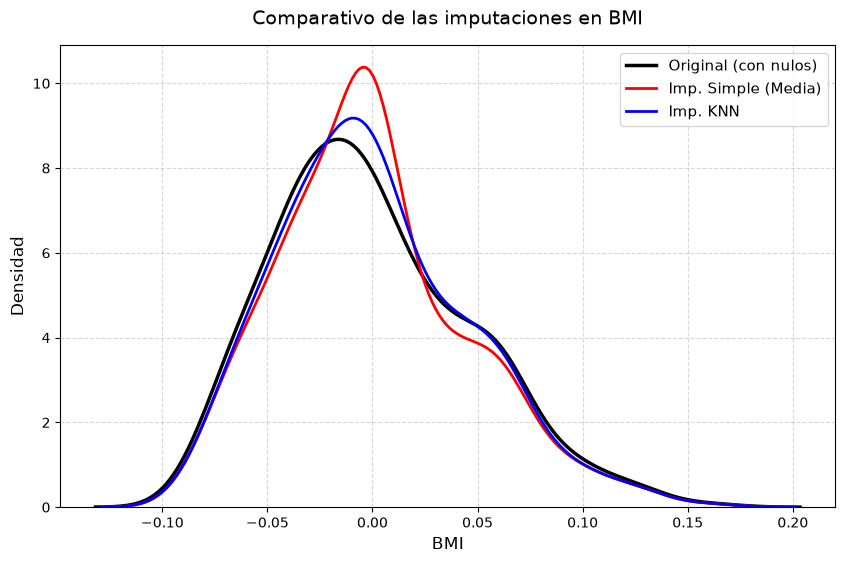

In [30]:
# Configurar el tamaño del gráfico
plt.figure(figsize=(10, 6))

# Graficar las distintas distribuciones
sns.kdeplot(data['bmi'], label='Original (con nulos)', color='black', linewidth=2.5)
sns.kdeplot(data_simpleimputer['bmi'], label='Imp. Simple (Media)', color='red', linewidth=2)
sns.kdeplot(data_knnimputer['bmi'], label='Imp. KNN', color='blue', linewidth=2)

plt.title('Comparativo de las imputaciones en BMI', fontsize=14, pad=15)
plt.xlabel('BMI', fontsize=12)
plt.ylabel('Densidad', fontsize=12)
plt.legend(fontsize=11)
plt.grid(linestyle='--', alpha=0.5)

# Mostrar el gráfico
plt.show()

